In [2]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from diffgeo import Tensor, TensorEvaluator, create_metric_tensors, create_gamma_tensor


In [3]:
coords_str = 'x y'

def my_metric(sp, x, y):
    # Example 2D metric (diagonal)
    return [
        [1 + x**2, 0],
        [0, 1 + y**2]
    ]

g_down, g_up = create_metric_tensors(coords_str, my_metric)

Gamma_tensor = create_gamma_tensor(g_down, g_up)
Gamma_eval = TensorEvaluator(Gamma_tensor)

In [4]:
def geodesic_ode_tensor(t, Y):
    X = Y[:2]      # position [x, y]
    V = Y[2:]      # velocity [dx/dt, dy/dt]
    
    # Evaluate Christoffels at current point
    Gamma_num = Gamma_eval.at(x=X[0], y=X[1])
    
    dXdt = V
    dVdt = np.zeros(2)
    
    # d^2 x^i/dt^2 = - Γ^i_jk v^j v^k
    for i in range(2):
        total = 0
        for j in range(2):
            for k in range(2):
                total += Gamma_num[(i,j,k)] * V[j] * V[k]
        dVdt[i] = -total
    
    return np.concatenate([dXdt, dVdt])
    

In [7]:
# Initial conditions: start at (1,1), moving along x
Y0 = np.array([1.0, 1.0, 1.0, sp.pi / 2])
t_span = (0, 5)
t_eval = np.linspace(*t_span, 200)

sol = solve_ivp(geodesic_ode_tensor, t_span, Y0, t_eval=t_eval)


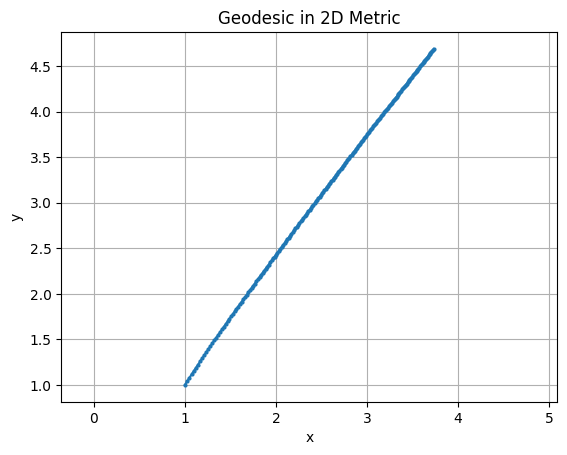

In [8]:
plt.plot(sol.y[0], sol.y[1], '-o', markersize=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Geodesic in 2D Metric')
plt.axis('equal')
plt.grid(True)
plt.show()
